In [1]:
import os
# --- 0. FIX for OpenMP Error ---
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import glob
import h5py
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import time # To time execution

print(f"TensorFlow Version: {tf.__version__}")

# --- 1. Parameters ---
NUM_POINTS = 1024
NUM_CLASSES = 16   # ShapeNetPart has 16 object categories
BATCH_SIZE = 8     # SAFETY EDIT: Small batch size
EPOCHS = 1         # SAFETY EDIT: Few epochs

# --- !! IMPORTANT: VERIFY THIS PATH !! ---
# Should point to the folder containing train*.h5, test*.h5 etc.
# (e.g., "C:/Users/YourUser/.../shapenetpart_hdf5_2048")
DATA_DIR = r"C:\Users\phane\OneDrive\Documents\Collge Internship Work (NITPY)\shapenetpart_hdf5_2048_3D_Project\shapenetpart_hdf5_2048"
MODEL_SAVE_PATH = "shapenet_classifier_model.keras"

# --- Category Names Mapping ---
category_names = [
    "Airplane",    # 0
    "Bag",         # 1
    "Cap",         # 2
    "Car",         # 3
    "Chair",       # 4
    "Earphone",    # 5
    "Guitar",      # 6
    "Knife",       # 7
    "Lamp",        # 8
    "Laptop",      # 9
    "Motorbike",   # 10
    "Mug",         # 11
    "Pistol",      # 12
    "Rocket",      # 13
    "Skateboard",  # 14
    "Table"        # 15
]

# --- 2. Data Loading ---
def load_shapenet_data(data_dir):
    """Loads ShapeNetPart h5 files (train*.h5, test*.h5)."""
    start_time = time.time()
    if not os.path.isdir(data_dir):
         print(f"❌ ERROR: DATA_DIR does not exist: {data_dir}")
         return None, None, None, None

    train_files = glob.glob(os.path.join(data_dir, "train*.h5"))
    test_files = glob.glob(os.path.join(data_dir, "test*.h5"))

    if not train_files:
        print(f"❌ ERROR: No 'train*.h5' files found directly inside '{data_dir}'")
        return None, None, None, None
    if not test_files:
         print(f"❌ ERROR: No 'test*.h5' files found directly inside '{data_dir}'")
         return None, None, None, None

    print(f"Found {len(train_files)} training H5 file parts.")
    print(f"Found {len(test_files)} test H5 file parts.")

    try:
        # Load train data
        train_data = []
        train_labels = []
        print("Loading training files...")
        for i, h5_file in enumerate(train_files):
            # print(f"  Loading {os.path.basename(h5_file)}...") # Optional: print progress
            with h5py.File(h5_file, 'r') as f:
                train_data.append(f['data'][:])
                train_labels.append(f['label'][:])

        # Load test data
        test_data = []
        test_labels = []
        print("Loading test files...")
        for i, h5_file in enumerate(test_files):
            # print(f"  Loading {os.path.basename(h5_file)}...") # Optional: print progress
             with h5py.File(h5_file, 'r') as f:
                test_data.append(f['data'][:])
                test_labels.append(f['label'][:])

        print("Concatenating data...")
        train_points = np.concatenate(train_data, axis=0)
        train_labels = np.concatenate(train_labels, axis=0).squeeze()
        test_points = np.concatenate(test_data, axis=0)
        test_labels = np.concatenate(test_labels, axis=0).squeeze()

        end_time = time.time()
        print(f"Data loaded successfully in {end_time - start_time:.2f} seconds.")
        return train_points, train_labels, test_points, test_labels

    except Exception as e:
        print(f"❌ ERROR loading H5 files: {e}")
        return None, None, None, None

# --- Load the data ---
print(f"Looking for data in: {os.path.abspath(DATA_DIR)}")
train_points, train_labels, test_points, test_labels = load_shapenet_data(DATA_DIR)

if train_points is not None:
    print(f"\nTrain data shape: {train_points.shape}, Train labels shape: {train_labels.shape}")
    print(f"Test data shape: {test_points.shape}, Test labels shape: {test_labels.shape}")
    print(f"Unique train labels: {np.unique(train_labels)}")
    print(f"Unique test labels: {np.unique(test_labels)}")
else:
    print("\nData loading failed. Please check DATA_DIR path and file integrity.")

# <<< GPU Check >>>
print("\n--- GPU/CUDA Check ---")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"✅ CUDA GPU found and available!")
        print(f"   Physical GPUs: {len(gpus)}")
        print(f"   Logical GPUs (TensorFlow will use): {len(logical_gpus)}")
        for gpu in gpus: print(f"   - Name: {gpu.name}")
    except RuntimeError as e:
        print(f"⚠️ Warning during GPU setup: {e}")
else:
    print("❌ No CUDA GPU found. TensorFlow will use the CPU.")
print("--------------------\n")

TensorFlow Version: 2.20.0
Looking for data in: C:\Users\phane\OneDrive\Documents\Collge Internship Work (NITPY)\shapenetpart_hdf5_2048_3D_Project\shapenetpart_hdf5_2048
Found 6 training H5 file parts.
Found 2 test H5 file parts.
Loading training files...
Loading test files...
Concatenating data...
Data loaded successfully in 1.30 seconds.

Train data shape: (12137, 2048, 3), Train labels shape: (12137,)
Test data shape: (2874, 2048, 3), Test labels shape: (2874,)
Unique train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Unique test labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]

--- GPU/CUDA Check ---
❌ No CUDA GPU found. TensorFlow will use the CPU.
--------------------




Creating tf.data.Dataset pipelines...
tf.data.Dataset created successfully.

Displaying one sample point cloud...


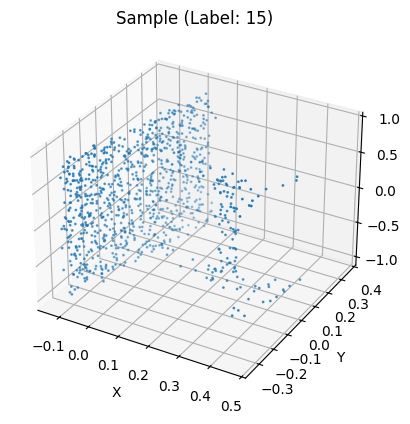

In [2]:
# --- 3. Preprocessing & Augmentation (PURE TENSORFLOW) ---
@tf.function
def preprocess_and_augment_tf(points):
    """Samples, normalizes, and augments using TensorFlow ops."""
    points = tf.cast(points, dtype=tf.float32)
    indices = tf.random.shuffle(tf.range(tf.shape(points)[0]))[:NUM_POINTS]
    points = tf.gather(points, indices)
    centroid = tf.reduce_mean(points, axis=0)
    points -= centroid
    dist = tf.reduce_max(tf.sqrt(tf.reduce_sum(tf.square(points), axis=1))) + 1e-8
    points /= dist
    jitter = tf.clip_by_value(0.01 * tf.random.normal(tf.shape(points)), -0.05, 0.05)
    points += jitter
    angle = tf.random.uniform([]) * 2.0 * tf.constant(np.pi, dtype=tf.float32)
    cosval = tf.cos(angle)
    sinval = tf.sin(angle)
    rotation_matrix = tf.convert_to_tensor([[cosval, -sinval, 0],[sinval, cosval, 0],[0, 0, 1]], dtype=tf.float32)
    points = tf.matmul(points, rotation_matrix)
    return points

@tf.function
def preprocess_test_tf(points):
    """Samples and normalizes using TensorFlow ops."""
    points = tf.cast(points, dtype=tf.float32)
    indices = tf.random.shuffle(tf.range(tf.shape(points)[0]))[:NUM_POINTS]
    points = tf.gather(points, indices)
    centroid = tf.reduce_mean(points, axis=0)
    points -= centroid
    dist = tf.reduce_max(tf.sqrt(tf.reduce_sum(tf.square(points), axis=1))) + 1e-8
    points /= dist
    return points

# --- 4. Visualization Function ---
def display_point_cloud(points, title="Point Cloud"):
    if isinstance(points, tf.Tensor):
        points = points.numpy()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1)
    ax.set_title(title)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    # plt.show() # In notebooks, plotting usually shows automatically. Use plt.show() if needed.

# --- Create tf.data Datasets ---
if train_points is not None:
    print("\nCreating tf.data.Dataset pipelines...")
    try:
        train_dataset = tf.data.Dataset.from_tensor_slices((train_points, train_labels))
        train_dataset = train_dataset.shuffle(buffer_size=10000) # Larger buffer if memory allows
        train_dataset = train_dataset.map(lambda p, l: (preprocess_and_augment_tf(p), l), num_parallel_calls=tf.data.AUTOTUNE)
        train_dataset = train_dataset.batch(BATCH_SIZE, drop_remainder=True)
        train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

        test_dataset = tf.data.Dataset.from_tensor_slices((test_points, test_labels))
        test_dataset = test_dataset.map(lambda p, l: (preprocess_test_tf(p), l), num_parallel_calls=tf.data.AUTOTUNE)
        test_dataset = test_dataset.batch(BATCH_SIZE, drop_remainder=True)
        test_dataset = test_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
        print("tf.data.Dataset created successfully.")

        # --- Display a sample ---
        print("\nDisplaying one sample point cloud...")
        sample_batch = next(iter(train_dataset))
        display_point_cloud(sample_batch[0][0], title=f"Sample (Label: {sample_batch[1][0].numpy()})")
        plt.show() # Explicitly show plot in notebook cell

    except Exception as e:
        print(f"❌ ERROR creating tf.data pipeline or displaying sample: {e}")
        # Set datasets to None to prevent further errors
        train_dataset = None
        test_dataset = None
else:
    print("\nSkipping dataset creation due to previous data loading error.")
    train_dataset = None
    test_dataset = None

In [3]:
# --- 5. PointNet++ Model Architecture ---
def conv_bn_relu(x, filters, kernel_size=1):
    x = layers.Conv1D(filters, kernel_size, padding="valid")(x)
    x = layers.BatchNormalization(momentum=0.0)(x)
    return layers.Activation("relu")(x)

def dense_bn_relu(x, units):
    x = layers.Dense(units)(x)
    x = layers.BatchNormalization(momentum=0.0)(x)
    return layers.Activation("relu")(x)

@tf.function
def farthest_point_sample(points, num_samples):
    batch_size = tf.shape(points)[0]
    num_points = tf.shape(points)[1]
    indices = tf.TensorArray(tf.int32, size=num_samples, dynamic_size=False, infer_shape=False)
    distances = tf.fill([batch_size, num_points], tf.constant(1e10, dtype=tf.float32))
    first_point_idx = tf.zeros([batch_size], dtype=tf.int32)
    indices = indices.write(0, first_point_idx)
    first_point = tf.gather(points, first_point_idx, batch_dims=1)
    first_point = tf.expand_dims(first_point, axis=1)
    dist = tf.reduce_sum(tf.square(points - first_point), axis=-1)
    distances = tf.minimum(distances, dist)
    for i in tf.range(1, num_samples):
        farthest_idx = tf.argmax(distances, axis=1, output_type=tf.int32)
        indices = indices.write(i, farthest_idx)
        farthest_point = tf.gather(points, farthest_idx, batch_dims=1)
        farthest_point = tf.expand_dims(farthest_point, axis=1)
        new_dist = tf.reduce_sum(tf.square(points - farthest_point), axis=-1)
        distances = tf.minimum(distances, new_dist)
    indices = indices.stack()
    indices = tf.transpose(indices, [1, 0])
    return indices

class PointNetSetAbstraction(layers.Layer):
    def __init__(self, n_samples, mlp_filters, name=None, **kwargs):
        super(PointNetSetAbstraction, self).__init__(name=name, **kwargs)
        self.n_samples = n_samples
        self.mlp_filters = mlp_filters
        self.mlp_layers = []
        for i, filters in enumerate(mlp_filters):
            self.mlp_layers.append(keras.Sequential([
                layers.Conv1D(filters, 1, activation='relu', padding='valid', name=f"mlp_{i}_conv"),
                layers.BatchNormalization(name=f"mlp_{i}_bn")
            ], name=f"mlp_{i}"))

    @tf.function
    def call(self, inputs):
        points, features = inputs
        if self.n_samples is not None:
            fps_indices = farthest_point_sample(points, self.n_samples)
            new_points = tf.gather(points, fps_indices, batch_dims=1)
        else:
            new_points = None
        x = features if features is not None else points
        for mlp in self.mlp_layers:
            x = mlp(x)
        if self.n_samples is not None:
            # Check if feature dim matches point dim before gathering
            if tf.shape(x)[1] == tf.shape(points)[1]:
                 new_features = tf.gather(x, fps_indices, batch_dims=1)
            else:
                 # Fallback, should not happen with Conv1D valid padding
                 tf.print("Warning: SA Layer feature dim mismatch, using max pool.")
                 new_features = tf.reduce_max(x, axis=1, keepdims=True)
        else:
            new_features = tf.reduce_max(x, axis=1, keepdims=True)
        return [new_points, new_features]

    def get_config(self):
        config = super().get_config()
        config.update({"n_samples": self.n_samples,"mlp_filters": self.mlp_filters})
        return config

def create_pointnet_plus_plus_clf(num_points, num_classes):
    points_input = keras.Input(shape=(num_points, 3), name="points_input")
    sa1_points, sa1_features = PointNetSetAbstraction(n_samples=512, mlp_filters=[64, 64, 128], name="sa1")([points_input, None])
    sa2_points, sa2_features = PointNetSetAbstraction(n_samples=128, mlp_filters=[128, 128, 256], name="sa2")([sa1_points, sa1_features])
    _, sa3_features = PointNetSetAbstraction(n_samples=None, mlp_filters=[256, 512, 1024], name="sa_global")([sa2_points, sa2_features])
    global_features = layers.Reshape((sa3_features.shape[-1],), name="global_reshape")(sa3_features)
    x = dense_bn_relu(global_features, 512)
    x = layers.Dropout(0.5)(x)
    x = dense_bn_relu(x, 256)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(num_classes, activation="softmax", name="output")(x)
    model = keras.Model(inputs=points_input, outputs=output, name="pointnet_plus_plus_clf")
    return model

# --- Build, Compile, Train ---
if train_dataset is not None: # Only proceed if data loading and dataset creation succeeded
    print("\nBuilding model...")
    try:
        model = create_pointnet_plus_plus_clf(num_points=NUM_POINTS, num_classes=NUM_CLASSES)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="sparse_categorical_crossentropy",
            metrics=["sparse_categorical_accuracy"]
        )
        print("Model built and compiled successfully.")
        model.summary() # Show model structure after building
    except Exception as e:
        print(f"❌ ERROR building or compiling model: {e}")
        model = None # Ensure model is None if build fails

    if model is not None:
        print("\nStarting training...")
        start_train_time = time.time()
        try:
            if gpus: # Check if GPUs are available (variable from Cell 1)
                mem_info_before = tf.config.experimental.get_memory_info('GPU:0')
                print(f"  GPU Memory Before Training: Used={mem_info_before['current'] / 1e9:.2f} GB")

            history = model.fit(
                train_dataset,
                epochs=EPOCHS,
                validation_data=test_dataset,
                verbose=1
            )
            end_train_time = time.time()
            print(f"Training finished in {end_train_time - start_train_time:.2f} seconds.")

            if gpus:
                mem_info_after = tf.config.experimental.get_memory_info('GPU:0')
                print(f"  GPU Memory After Training: Used={mem_info_after['current'] / 1e9:.2f} GB (Peak={mem_info_after['peak'] / 1e9:.2f} GB during training)")

            # --- Save the Trained Model ---
            print("\nSaving the trained model...")
            try:
                model.save(MODEL_SAVE_PATH)
                print(f"Model saved successfully to {MODEL_SAVE_PATH}")
            except Exception as e:
                print(f"❌ ERROR saving model: {e}")

        except Exception as e:
             print(f"❌ ERROR during training: {e}")
             # Model might be partially trained, but saving might fail
             model = None # Indicate training didn't complete fully

else:
    print("\nSkipping model training due to previous errors.")
    model = None # Ensure model is None if data failed to load


Building model...
❌ ERROR building or compiling model: 'NoneType' object has no attribute 'shape'


In [4]:
# --- Evaluate Model ---
if 'model' in locals() and model is not None and test_dataset is not None: # Check if model and test_dataset exist
    print("\nEvaluating model on test set...")
    try:
        loss, accuracy = model.evaluate(test_dataset, verbose=1) # Show progress bar
        print(f"\nTest Loss: {loss:.4f}")
        print(f"Test Accuracy: {accuracy*100:.2f}%")
    except Exception as e:
        print(f"❌ ERROR during evaluation: {e}")
else:
    print("\nSkipping evaluation because the model was not trained or test data is unavailable.")


Skipping evaluation because the model was not trained or test data is unavailable.


In [5]:
# --- Load Saved Model ---
# You can run this cell instead of Cell 3 after the model has been saved once.

print(f"\nLoading model from {MODEL_SAVE_PATH}...")
if os.path.exists(MODEL_SAVE_PATH):
    try:
        # Need to register the custom layer when loading
        loaded_model = keras.models.load_model(
            MODEL_SAVE_PATH,
            custom_objects={'PointNetSetAbstraction': PointNetSetAbstraction}
        )
        print("Model loaded successfully from file.")
        # Optionally assign to the main 'model' variable if you want to use it below
        # model = loaded_model
    except Exception as e:
        print(f"❌ ERROR loading saved model: {e}")
        loaded_model = None
else:
    print(f"Model file '{MODEL_SAVE_PATH}' not found. Train the model first (run Cell 3).")
    loaded_model = None # Ensure variable exists


Loading model from shapenet_classifier_model.keras...
❌ ERROR loading saved model: File not found: filepath=shapenet_classifier_model.keras. Please ensure the file is an accessible `.keras` zip file.


In [6]:
# --- Classify a Single Object Example ---
# This cell uses the 'model' variable from training (Cell 3)
# OR you can uncomment the line in Cell 5 to use the 'loaded_model'.

# Make sure a model is available (either trained in this session or loaded)
current_model = None
if 'loaded_model' in locals() and loaded_model is not None:
    current_model = loaded_model
    print("\nUsing model loaded from file for single classification.")
elif 'model' in locals() and model is not None:
    current_model = model
    print("\nUsing model trained in this session for single classification.")
else:
    print("\nNo trained or loaded model available. Skipping single object classification.")


if current_model is not None and test_points is not None: # Check if model and test data exist
    print("\n--- Classifying a single object ---")
    try:
        object_index = 5 # <<< You can change this index!
        if object_index >= len(test_points):
             print(f"❌ ERROR: object_index {object_index} is too large. Max index is {len(test_points)-1}. Using index 0 instead.")
             object_index = 0

        single_object_raw = test_points[object_index]
        true_label_index = test_labels[object_index]
        true_name = category_names[true_label_index]
        print(f"Loading object index {object_index} (True Label: {true_label_index} - {true_name})...")

        # Use the TF preprocessing function
        single_object_processed = preprocess_test_tf(tf.constant(single_object_raw)) # Tensor output

        # Add Batch Dimension using TensorFlow
        single_object_batch = tf.expand_dims(single_object_processed, axis=0)
        print(f"Input shape for prediction: {single_object_batch.shape}")

        print("Running prediction...")
        predictions = current_model.predict(single_object_batch)

        predicted_class_index = np.argmax(predictions[0])
        confidence = np.max(predictions[0])
        predicted_name = category_names[predicted_class_index]

        print(f"\nModel Prediction:")
        print(f"  - Predicted Class: {predicted_class_index} ({predicted_name})")
        print(f"  - Confidence: {confidence*100:.2f}%")
        print(f"  - True Class:      {true_label_index} ({true_name})")

        print("\nDisplaying the object...")
        display_point_cloud(
            single_object_processed, # Pass the tensor
            title=f"Object {object_index} (True: {true_name}, Pred: {predicted_name})"
        )
        plt.show() # Ensure plot shows in this cell

    except Exception as e:
        print(f"❌ ERROR during single object classification: {e}")


No trained or loaded model available. Skipping single object classification.
